# CardioIA – Fase 4: Assistente Cardiológico Virtual com Visão Computacional

Nesta fase, o projeto CardioIA avança para o uso de Visão Computacional aplicada à análise de imagens médicas simuladas.

O objetivo deste notebook é construir um protótipo capaz de:

- organizar e pré-processar imagens de ECG;
- treinar uma CNN simples do zero;
- aplicar Transfer Learning com modelo pré-treinado;
- avaliar os resultados com métricas;
- apresentar uma classificação simulada em formato de protótipo interativo.

O projeto possui finalidade acadêmica e não substitui avaliação médica profissional.

In [4]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix

print("TensorFlow:", tf.__version__)

TensorFlow: 2.20.0


In [3]:
import os

# O dataset já foi enviado e extraído no ambiente do Google Colab.
# A pasta principal utilizada será:
base_dir = "/content/ecg_dataset/ECG_DATA"

train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

print("Dataset localizado com sucesso.")
print("Pasta de treino:", train_dir)
print("Pasta de teste:", test_dir)

Dataset localizado com sucesso.
Pasta de treino: /content/ecg_dataset/ECG_DATA/train
Pasta de teste: /content/ecg_dataset/ECG_DATA/test


In [3]:
print("\nClasses encontradas:")

classes = os.listdir(train_dir)

for classe in classes:
    caminho_classe = os.path.join(train_dir, classe)
    quantidade = len(os.listdir(caminho_classe))

    print(classe)
    print("Quantidade:", quantidade)
    print("-" * 40)


Classes encontradas:
ECG Images of Patient that have abnormal heartbeat (233x12=2796)
Quantidade: 699
----------------------------------------
ECG Images of Patient that have History of MI (172x12=2064)
Quantidade: 516
----------------------------------------
ECG Images of Myocardial Infarction Patients (240x12=2880)
Quantidade: 956
----------------------------------------
Normal Person ECG Images (284x12=3408)
Quantidade: 852
----------------------------------------


In [6]:
img_altura = 224
img_largura = 224
batch_size = 32

gerador_treino = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20
)

gerador_teste = ImageDataGenerator(
    rescale=1./255
)

treino = gerador_treino.flow_from_directory(
    train_dir,
    target_size=(img_altura, img_largura),
    batch_size=batch_size,
    class_mode="categorical",
    subset="training"
)

validacao = gerador_treino.flow_from_directory(
    train_dir,
    target_size=(img_altura, img_largura),
    batch_size=batch_size,
    class_mode="categorical",
    subset="validation"
)

teste = gerador_teste.flow_from_directory(
    test_dir,
    target_size=(img_altura, img_largura),
    batch_size=batch_size,
    class_mode="categorical",
    shuffle=False
)

print("Pré-processamento concluído.")

Found 2420 images belonging to 4 classes.
Found 603 images belonging to 4 classes.
Found 928 images belonging to 4 classes.
Pré-processamento concluído.


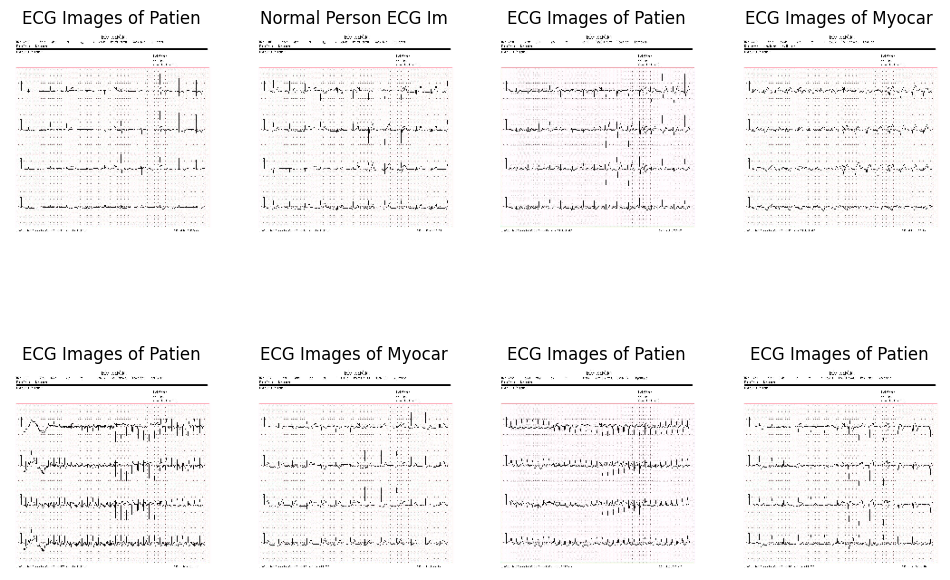

In [7]:
imagens, rotulos = next(treino)

nomes_classes = list(treino.class_indices.keys())

plt.figure(figsize=(12,8))

for i in range(8):
    plt.subplot(2,4,i+1)

    plt.imshow(imagens[i])

    indice = np.argmax(rotulos[i])

    plt.title(nomes_classes[indice][:20])

    plt.axis("off")

plt.show()

## Resumo do Pré-processamento

Nesta etapa foi realizado o carregamento do dataset de ECG, seguido da organização das imagens em conjuntos de treino, validação e teste.

As imagens foram redimensionadas para 224x224 pixels e normalizadas para valores entre 0 e 1 através da técnica de rescale.

Também foi aplicada a separação automática de 20% das imagens para validação do modelo.

Essas etapas garantem que os modelos de Visão Computacional recebam dados padronizados para treinamento e avaliação.

# Parte 2 - Treinamento de uma CNN do Zero

Nesta etapa será criada uma Rede Neural Convolucional simples para classificação das imagens de ECG.

O objetivo é identificar padrões visuais presentes nos exames e classificá-los em uma das quatro categorias disponíveis no dataset.

In [8]:
modelo_cnn = models.Sequential([

    layers.Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(224,224,3)
    ),

    layers.MaxPooling2D((2,2)),

    layers.Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    layers.MaxPooling2D((2,2)),

    layers.Flatten(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        4,
        activation="softmax"
    )
])

modelo_cnn.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 186624)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    23,888,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,907,908 (91.20 MB)

 Trainable params: 23,907,908 (91.20 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
modelo_cnn.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Modelo compilado com sucesso.")

Modelo compilado com sucesso.


In [10]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [11]:
historico_cnn = modelo_cnn.fit(
    treino,
    validation_data=validacao,
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.3029 - loss: 2.5904 - val_accuracy: 0.3167 - val_loss: 1.3738
Epoch 2/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 76s 996ms/step - accuracy: 0.3161 - loss: 1.3687 - val_accuracy: 0.3167 - val_loss: 1.3643
Epoch 3/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 71s 938ms/step - accuracy: 0.3161 - loss: 1.3630 - val_accuracy: 0.3167 - val_loss: 1.3617
Epoch 4/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 73s 969ms/step - accuracy: 0.3161 - loss: 1.3625 - val_accuracy: 0.3167 - val_loss: 1.3613
Epoch 5/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 76s 996ms/step - accuracy: 0.3161 - loss: 1.3628 - val_accuracy: 0.3167 - val_loss: 1.3613


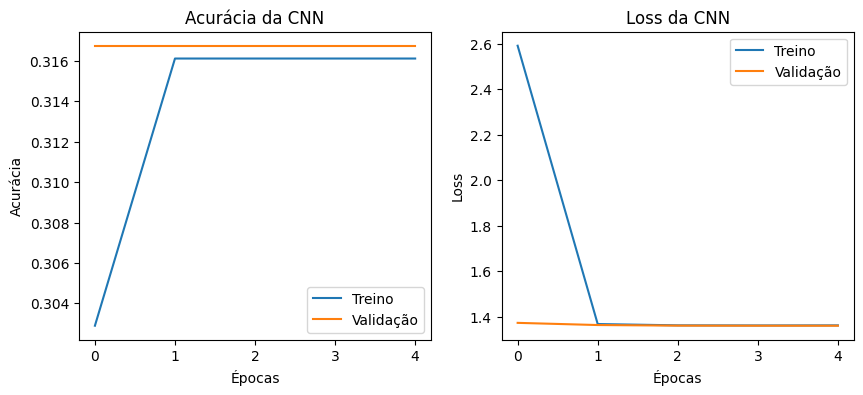

In [12]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(historico_cnn.history["accuracy"], label="Treino")
plt.plot(historico_cnn.history["val_accuracy"], label="Validação")
plt.title("Acurácia da CNN")
plt.xlabel("Épocas")
plt.ylabel("Acurácia")
plt.legend()

plt.subplot(1,2,2)
plt.plot(historico_cnn.history["loss"], label="Treino")
plt.plot(historico_cnn.history["val_loss"], label="Validação")
plt.title("Loss da CNN")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()

plt.show()

In [13]:
resultado_teste = modelo_cnn.evaluate(teste)

print("Loss no teste:", resultado_teste[0])
print("Acurácia no teste:", resultado_teste[1])

29/29 ━━━━━━━━━━━━━━━━━━━━ 23s 786ms/step - accuracy: 0.2575 - loss: 1.3790
Loss no teste: 1.3790011405944824
Acurácia no teste: 0.2575431168079376


In [14]:
predicoes = modelo_cnn.predict(teste)

y_pred = np.argmax(predicoes, axis=1)
y_true = teste.classes

nomes_classes = list(teste.class_indices.keys())

print("Predições geradas com sucesso.")

29/29 ━━━━━━━━━━━━━━━━━━━━ 23s 769ms/step
Predições geradas com sucesso.


In [26]:
img_array = image.img_to_array(img)

img_array = img_array / 255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

predicao = modelo_cnn.predict(img_array)

indice_previsto = np.argmax(predicao)

classe_prevista = nomes_classes[
    indice_previsto
]

confianca = np.max(predicao) * 100

print("=== RESULTADO DO ASSISTENTE CARDIOLÓGICO ===")

print("\nClasse Real:")
print(classe_escolhida)

print("\nClasse Prevista:")
print(classe_prevista)

print("\nConfiança:")
print(f"{confianca:.2f}%")

if classe_escolhida == classe_prevista:
    print("\nResultado: Classificação correta.")
else:
    print("\nResultado: Classificação incorreta.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 918ms/step
=== RESULTADO DO ASSISTENTE CARDIOLÓGICO ===

Classe Real:
Normal Person ECG Images (284x12=3408)

Classe Prevista:
ECG Images of Myocardial Infarction Patients (240x12=2880)

Confiança:
31.46%

Resultado: Classificação incorreta.


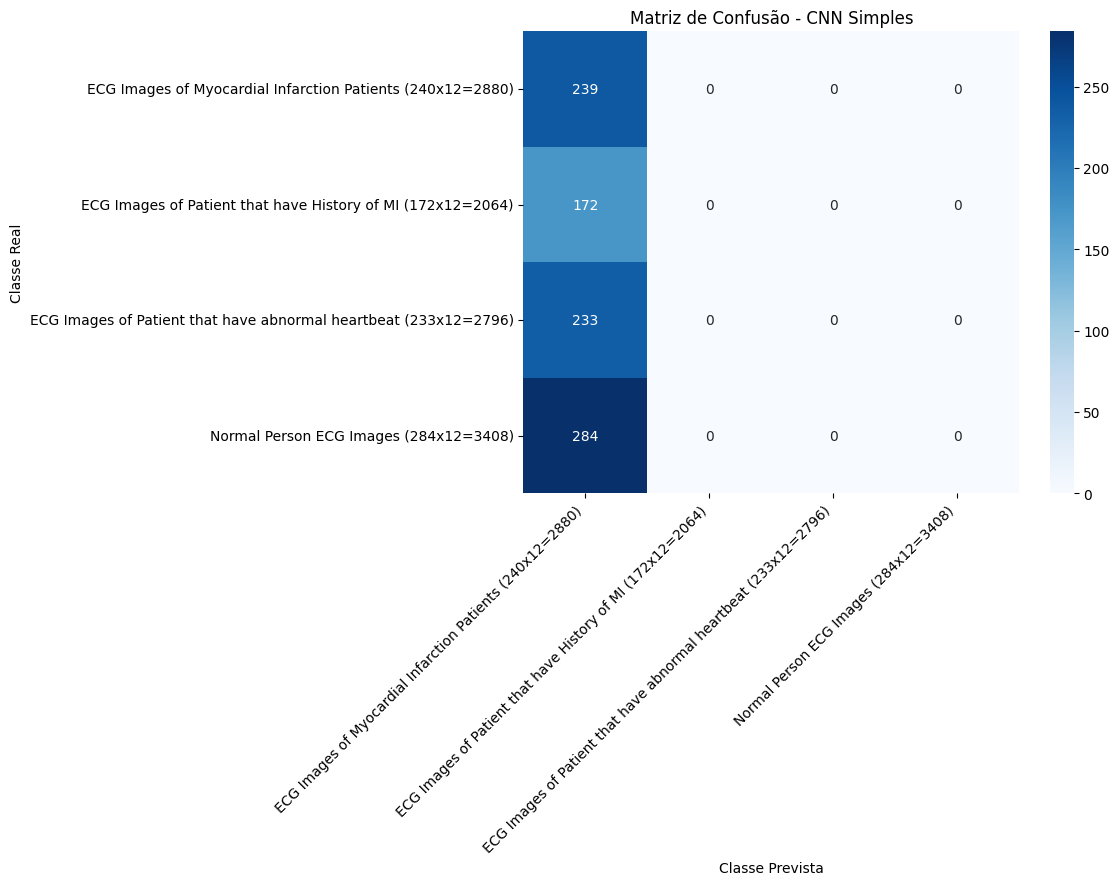

In [15]:
matriz = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    matriz,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=nomes_classes,
    yticklabels=nomes_classes
)

plt.title("Matriz de Confusão - CNN Simples")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.show()

In [16]:
print(
    classification_report(
        y_true,
        y_pred,
        target_names=nomes_classes
    )
)

                                                                  precision    recall  f1-score   support

      ECG Images of Myocardial Infarction Patients (240x12=2880)       0.26      1.00      0.41       239
     ECG Images of Patient that have History of MI (172x12=2064)       0.00      0.00      0.00       172
ECG Images of Patient that have abnormal heartbeat (233x12=2796)       0.00      0.00      0.00       233
                          Normal Person ECG Images (284x12=3408)       0.00      0.00      0.00       284

                                                        accuracy                           0.26       928
                                                       macro avg       0.06      0.25      0.10       928
                                                    weighted avg       0.07      0.26      0.11       928



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Resultados da CNN Simples

Após o treinamento da Rede Neural Convolucional desenvolvida do zero, o modelo apresentou baixo desempenho no conjunto de teste.

A acurácia obtida foi de aproximadamente 25,8%, indicando que a CNN simples não conseguiu generalizar bem os padrões das imagens de ECG.

Na matriz de confusão e no relatório de classificação, foi possível observar que o modelo concentrou muitas previsões em poucas classes, demonstrando limitação da arquitetura simples utilizada.

Esse resultado é importante para o projeto, pois mostra que nem sempre uma CNN construída do zero apresenta bom desempenho quando o problema envolve imagens médicas com características específicas.

# Parte 3 - Transfer Learning

Nesta etapa foi utilizada a técnica de Transfer Learning, aproveitando o conhecimento previamente aprendido por um modelo treinado em grandes bases de imagens.

O objetivo é comparar essa abordagem com a CNN desenvolvida do zero e verificar seu desempenho na classificação das imagens de ECG.

In [17]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

base_model.trainable = False

modelo_tl = models.Sequential([

    base_model,

    layers.GlobalAveragePooling2D(),

    layers.Dense(
        128,
        activation="relu"
    ),

    layers.Dropout(0.3),

    layers.Dense(
        4,
        activation="softmax"
    )
])

modelo_tl.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,468 (9.24 MB)

 Trainable params: 164,484 (642.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:
modelo_tl.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Modelo de Transfer Learning compilado com sucesso.")

Modelo de Transfer Learning compilado com sucesso.


In [19]:
historico_tl = modelo_tl.fit(
    treino,
    validation_data=validacao,
    epochs=5,
    callbacks=[early_stop]
)

Epoch 1/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 127s 1s/step - accuracy: 0.4992 - loss: 1.1566 - val_accuracy: 0.6700 - val_loss: 0.8898
Epoch 2/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 75s 987ms/step - accuracy: 0.6764 - loss: 0.8542 - val_accuracy: 0.7479 - val_loss: 0.7462
Epoch 3/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 76s 1s/step - accuracy: 0.7207 - loss: 0.7382 - val_accuracy: 0.7529 - val_loss: 0.6420
Epoch 4/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 77s 1s/step - accuracy: 0.7372 - loss: 0.6748 - val_accuracy: 0.8093 - val_loss: 0.5736
Epoch 5/5
76/76 ━━━━━━━━━━━━━━━━━━━━ 78s 1s/step - accuracy: 0.7731 - loss: 0.6220 - val_accuracy: 0.8872 - val_loss: 0.4640


In [20]:
resultado_teste_tl = modelo_tl.evaluate(teste)

print("Loss no teste - Transfer Learning:", resultado_teste_tl[0])
print("Acurácia no teste - Transfer Learning:", resultado_teste_tl[1])

29/29 ━━━━━━━━━━━━━━━━━━━━ 24s 811ms/step - accuracy: 0.8481 - loss: 0.5234
Loss no teste - Transfer Learning: 0.5234434604644775
Acurácia no teste - Transfer Learning: 0.8480603694915771


In [21]:
predicoes_tl = modelo_tl.predict(teste)

y_pred_tl = np.argmax(predicoes_tl, axis=1)
y_true_tl = teste.classes

nomes_classes = list(teste.class_indices.keys())

print("Predições do Transfer Learning geradas com sucesso.")

29/29 ━━━━━━━━━━━━━━━━━━━━ 29s 785ms/step
Predições do Transfer Learning geradas com sucesso.


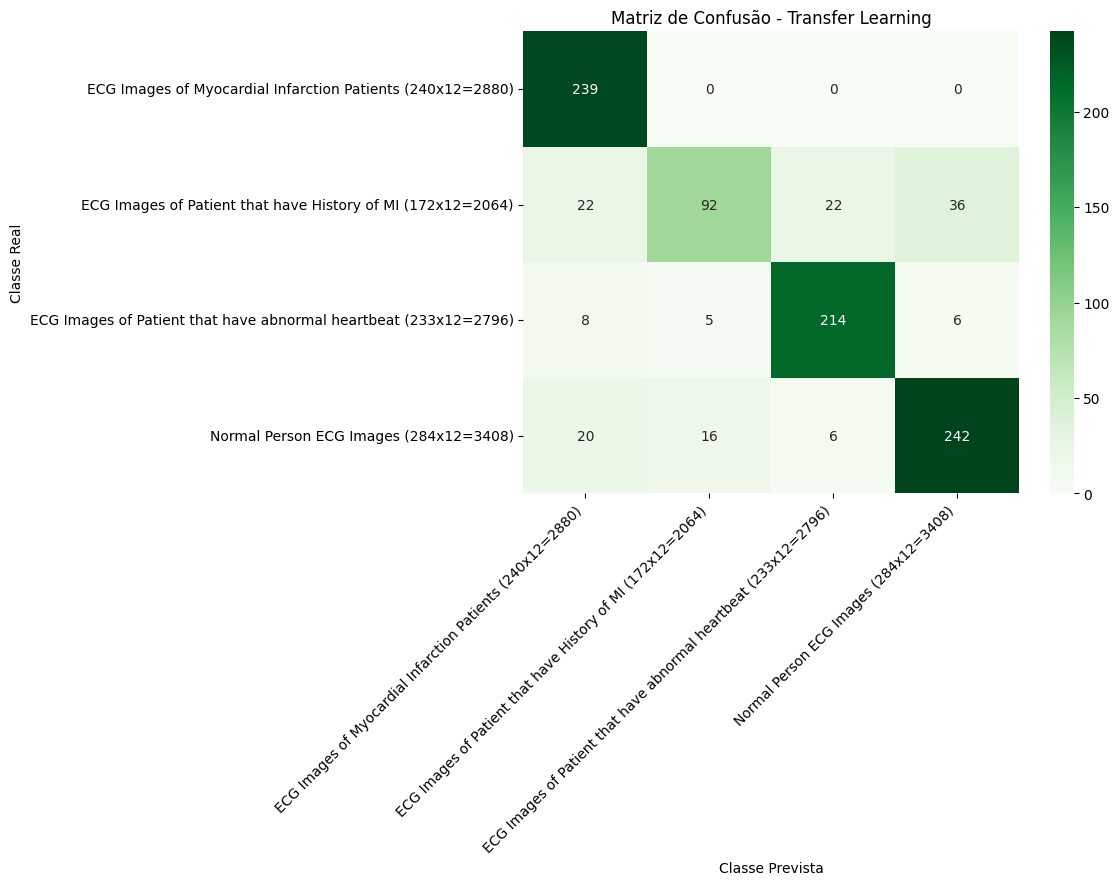

In [22]:
matriz_tl = confusion_matrix(y_true_tl, y_pred_tl)

plt.figure(figsize=(8,6))

sns.heatmap(
    matriz_tl,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=nomes_classes,
    yticklabels=nomes_classes
)

plt.title("Matriz de Confusão - Transfer Learning")
plt.xlabel("Classe Prevista")
plt.ylabel("Classe Real")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.show()

In [23]:
print(
    classification_report(
        y_true_tl,
        y_pred_tl,
        target_names=nomes_classes
    )
)

                                                                  precision    recall  f1-score   support

      ECG Images of Myocardial Infarction Patients (240x12=2880)       0.83      1.00      0.91       239
     ECG Images of Patient that have History of MI (172x12=2064)       0.81      0.53      0.65       172
ECG Images of Patient that have abnormal heartbeat (233x12=2796)       0.88      0.92      0.90       233
                          Normal Person ECG Images (284x12=3408)       0.85      0.85      0.85       284

                                                        accuracy                           0.85       928
                                                       macro avg       0.84      0.83      0.83       928
                                                    weighted avg       0.85      0.85      0.84       928



## Resultados do Transfer Learning

O modelo de Transfer Learning com MobileNetV2 foi treinado e avaliado no conjunto de teste.

Nesta abordagem, o desempenho foi superior ao da CNN construída do zero, atingindo aproximadamente 84,8% de acurácia.

Esse resultado demonstra a vantagem do uso de modelos pré-treinados, que já aprenderam padrões visuais em grandes bases de imagens e podem ser adaptados para novos problemas.

Mesmo utilizando imagens médicas de ECG, o Transfer Learning apresentou melhor capacidade de generalização em comparação com a CNN simples.

# Parte 4 - Protótipo de Assistente Cardiológico Virtual

Nesta etapa é apresentado um protótipo simples do Assistente Cardiológico Virtual.

O objetivo é simular como um profissional poderia enviar uma imagem de ECG e receber uma classificação automática produzida pelo modelo treinado.

In [24]:
import random
from tensorflow.keras.preprocessing import image

classe_escolhida = random.choice(nomes_classes)

pasta_classe = os.path.join(test_dir, classe_escolhida)

arquivo_imagem = random.choice(
    os.listdir(pasta_classe)
)

caminho_imagem = os.path.join(
    pasta_classe,
    arquivo_imagem
)

print("Classe real:")
print(classe_escolhida)

print("\nArquivo:")
print(arquivo_imagem)

Classe real:
Normal Person ECG Images (284x12=3408)

Arquivo:
Normal(74).jpg


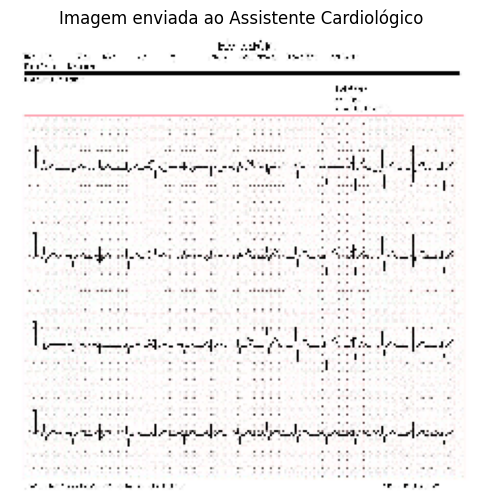

In [25]:
img = image.load_img(
    caminho_imagem,
    target_size=(224,224)
)

plt.figure(figsize=(6,6))
plt.imshow(img)
plt.title("Imagem enviada ao Assistente Cardiológico")
plt.axis("off")
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step


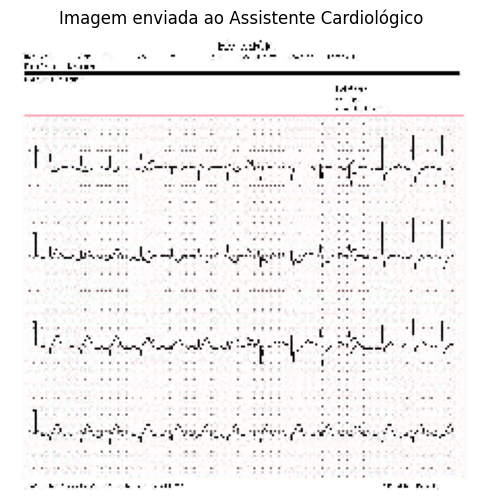

=== Resultado do Assistente Cardiológico Virtual ===
Classe Real: ECG Images of Myocardial Infarction Patients (240x12=2880)
Classe Prevista: ECG Images of Myocardial Infarction Patients (240x12=2880)
Confiança da Predição: 89.91%
Resultado: Classificação correta.


In [27]:
# =========================
# PROTÓTIPO DO ASSISTENTE CARDIOLÓGICO VIRTUAL
# =========================

import numpy as np
import matplotlib.pyplot as plt

# Selecionar uma imagem do conjunto de teste
imagem_teste, classe_real_num = teste[0]

# Pegar a primeira imagem do lote
imagem = imagem_teste[0]
classe_real = np.argmax(classe_real_num[0])

# Fazer predição com o modelo de Transfer Learning
predicao = modelo_tl.predict(np.expand_dims(imagem, axis=0))

classe_prevista = np.argmax(predicao)
confianca = np.max(predicao) * 100

nomes_classes = list(teste.class_indices.keys())

# Exibir imagem e resultado
plt.figure(figsize=(8, 6))
plt.imshow(imagem)
plt.axis("off")
plt.title("Imagem enviada ao Assistente Cardiológico")
plt.show()

print("=== Resultado do Assistente Cardiológico Virtual ===")
print("Classe Real:", nomes_classes[classe_real])
print("Classe Prevista:", nomes_classes[classe_prevista])
print(f"Confiança da Predição: {confianca:.2f}%")

if classe_real == classe_prevista:
    print("Resultado: Classificação correta.")
else:
    print("Resultado: Classificação incorreta.")

# Conclusão

Nesta fase do projeto CardioIA foi possível aplicar conceitos de Visão Computacional na análise de imagens de eletrocardiogramas.

Foram desenvolvidas duas abordagens distintas:

- CNN construída do zero;
- Transfer Learning utilizando MobileNetV2.

Os resultados mostraram que o modelo de Transfer Learning apresentou desempenho superior à CNN simples construída do zero.

A CNN simples obteve aproximadamente 25,8% de acurácia no conjunto de teste, enquanto o modelo com MobileNetV2 atingiu aproximadamente 84,8%.

Esse resultado reforça a importância do Transfer Learning em problemas de Visão Computacional, principalmente quando se trabalha com datasets específicos e com tempo limitado para treinamento.

Também foi desenvolvido um protótipo simples capaz de receber uma imagem de ECG e apresentar uma classificação automática com nível de confiança.

O projeto permitiu compreender na prática como técnicas de Inteligência Artificial podem auxiliar na interpretação de exames médicos, mantendo a consciência de que aplicações reais exigem validação clínica especializada, bases maiores e requisitos regulatórios específicos.

In [1]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [2]:
import zipfile
import os

zip_path = "/content/archive.zip"
extract_path = "/content/ecg_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

base_dir = "/content/ecg_dataset/ECG_DATA"
train_dir = os.path.join(base_dir, "train")
test_dir = os.path.join(base_dir, "test")

print("Train existe?", os.path.exists(train_dir))
print("Test existe?", os.path.exists(test_dir))
print("Classes:", os.listdir(train_dir))

Train existe? True
Test existe? True
Classes: ['ECG Images of Patient that have abnormal heartbeat (233x12=2796)', 'ECG Images of Patient that have History of MI (172x12=2064)', 'ECG Images of Myocardial Infarction Patients (240x12=2880)', 'Normal Person ECG Images (284x12=3408)']
